# 05 — Support Vector Machine (SVM)

**O que é:** algoritmo que encontra o hiperplano de margem máxima que separa as classes no espaço de features.

**Kernel RBF (Radial Basis Function):** transforma os dados em espaço de alta dimensão para tornar separáveis casos não-lineares.

**Vantagens:** eficiente em espaços de alta dimensão, robusto quando número de features > amostras.

**Desvantagens:** lento para grandes datasets, difícil de interpretar, sensível à escala (por isso normalizamos os dados).

## Carregamento e Preparação (igual aos notebooks anteriores)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)

FEATURES = ['Plantel', 'Estrangeiros', 'Valor de Mercado Total']
TARGET   = 'Status_bin'

df = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()
df[TARGET] = df['Situacao'].apply(lambda x: 0 if str(x).strip().lower() == 'rebaixado' else 1)

df_rot = df[df['Temporada'] < 2025].copy()
df_tr  = df_rot[df_rot['Temporada'] <= 2022]
df_te  = df_rot[df_rot['Temporada']  > 2022]

scaler = StandardScaler()
X_tr = scaler.fit_transform(df_tr[FEATURES])
y_tr = df_tr[TARGET].values
X_te = scaler.transform(df_te[FEATURES])
y_te = df_te[TARGET].values

print(f'Treino: {X_tr.shape} | Teste: {X_te.shape}')

Treino: (180, 3) | Teste: (40, 3)


## Treinamento do SVM

Usamos kernel RBF (padrão), `class_weight='balanced'` e `probability=True` para obter probabilidades.

In [2]:
svm = SVC(probability=True, random_state=42, class_weight='balanced', kernel='rbf')
svm.fit(X_tr, y_tr)

print('SVM treinado!')
print(f'Kernel: {svm.kernel} | C: {svm.C} | Gamma: {svm.gamma}')
print(f'Vetores de suporte: {svm.n_support_}  (por classe)')

SVM treinado!
Kernel: rbf | C: 1.0 | Gamma: scale
Vetores de suporte: [ 26 103]  (por classe)


## Avaliação no Conjunto de Teste

Acurácia no teste: 0.7250 (72.50%)

Relatório de Classificação:
              precision    recall  f1-score   support

   Rebaixado       0.40      0.20      0.27        10
  Permaneceu       0.77      0.90      0.83        30

    accuracy                           0.72        40
   macro avg       0.59      0.55      0.55        40
weighted avg       0.68      0.72      0.69        40



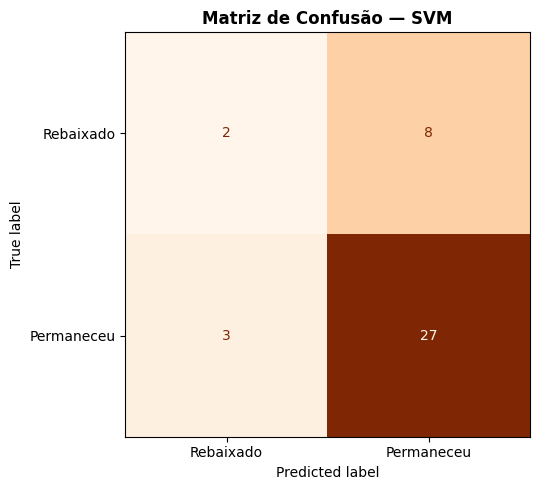

Matriz salva em img/cm_svm.png


In [3]:
y_pred = svm.predict(X_te)

acc = accuracy_score(y_te, y_pred)
print(f'Acurácia no teste: {acc:.4f} ({acc*100:.2f}%)')
print()
print('Relatório de Classificação:')
print(classification_report(y_te, y_pred, target_names=['Rebaixado', 'Permaneceu']))

# Matriz de Confusão
os.makedirs(os.path.join('..', 'img'), exist_ok=True)
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rebaixado', 'Permaneceu'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Matriz de Confusão — SVM', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'img', 'cm_svm.png'), dpi=150)
plt.show()
print('Matriz salva em img/cm_svm.png')

## Curva ROC e AUC

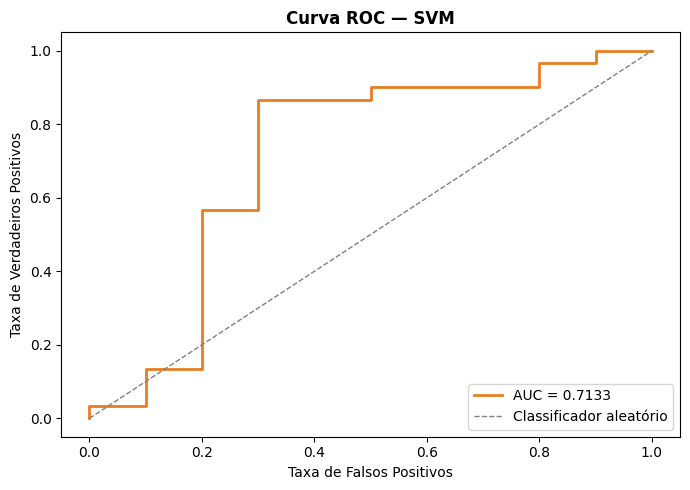

AUC: 0.7133 | Salvo em img/roc_svm.png


In [4]:
y_prob = svm.predict_proba(X_te)[:, 1]
fpr, tpr, _ = roc_curve(y_te, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#e67e22', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Classificador aleatório')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — SVM', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join('..', 'img', 'roc_svm.png'), dpi=150)
plt.show()
print(f'AUC: {roc_auc:.4f} | Salvo em img/roc_svm.png')

## Probabilidades por Clube no Conjunto de Teste

In [5]:
probs = svm.predict_proba(X_te)
idx_reb = list(svm.classes_).index(0)

df_res = df_te[['Clube', 'Temporada']].copy()
df_res['Prob_Rebaixamento(%)'] = (probs[:, idx_reb] * 100).round(2)
df_res['Real']     = y_te
df_res['Previsto'] = svm.predict(X_te)
df_res = df_res.sort_values('Prob_Rebaixamento(%)', ascending=False)

print('Probabilidades de rebaixamento (conjunto de teste):')
df_res

Probabilidades de rebaixamento (conjunto de teste):


,Clube,Temporada,Prob_Rebaixamento(%),Real,Previsto
124,Juventude,2024,37.08,0,0
31,Goiás,2023,29.87,1,0
61,Vitória,2024,29.86,0,0
190,Cuiabá,2023,24.29,1,0
193,Cuiabá,2024,21.56,1,0
110,América Mineiro,2023,17.47,0,1
51,Coritiba,2023,16.21,0,1
96,Atlético Goianiense,2024,15.87,0,1
9,Flamengo,2024,14.37,1,1
7,Vasco da,2023,14.22,0,1


## Salvando o Modelo

In [6]:
os.makedirs(os.path.join('..', 'modelos'), exist_ok=True)
joblib.dump(svm, os.path.join('..', 'modelos', 'svm.pkl'))
joblib.dump(scaler, os.path.join('..', 'modelos', 'scaler_svm.pkl'))
print('Modelo salvo em modelos/svm.pkl')
print('Scaler salvo em modelos/scaler_svm.pkl')

Modelo salvo em modelos/svm.pkl
Scaler salvo em modelos/scaler_svm.pkl


## Interpretação e Comparação

Descreva os resultados obtidos pelo SVM e compare com os modelos anteriores.

**Pontos a observar:**
- O SVM com kernel RBF pode capturar fronteiras de decisão não-lineares, o que pode ser uma vantagem sobre a Regressão Logística.
- Por não fornecer coeficientes diretos, a interpretabilidade é menor do que a Regressão Logística.
- O número de vetores de suporte indica a complexidade da fronteira aprendida: muitos vetores podem indicar overfitting.
- Com dados normalizados (StandardScaler), o SVM tende a ter desempenho mais estável.
- Compare AUC, precision e recall para a classe minoritária (Rebaixado) entre os três modelos treinados.